In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install pydicom

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 3.4 MB/s eta 0:00:00


In [ ]:
import os, glob
import sys
import copy
import pydicom
import random
import re
import scipy
import scipy.misc
import numpy as np
import cv2
import imageio
import seaborn as sns
import matplotlib.pyplot as plt
from PIL import Image, ImageEnhance
import tensorflow as tf
from tensorflow import keras
from scipy.ndimage import rotate
from skimage import exposure
from sklearn.metrics import confusion_matrix
from operator import add
plt.set_cmap('gray')
%matplotlib inline
## Seeding
seed = 2019
random.seed = seed
np.random.seed = seed
tf.seed = seed


IMG_DTYPE = np.float
SEG_DTYPE = np.uint8


<ipython-input-8-1619d7ba376c>:30: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  IMG_DTYPE = np.float


<Figure size 640x480 with 0 Axes>

In [ ]:
if tf.test.gpu_device_name():
    print('Default GPU Device: {}'.format(tf.test.gpu_device_name()))
else:
    print("Please install GPU version of TF")

Default GPU Device: /device:GPU:0


In [ ]:
#from google.colab import files

#files.upload()

In [ ]:
! mkdir ~/.kaggle
! cp /content/drive/MyDrive/LiverTumor-20231127T140824Z-001/LiverTumor/kaggle.json ~/.kaggle/
! chmod 600 ~/.kaggle/kaggle.json
! kaggle datasets download -d nguyenhoainam27/3dircadb

 91% 145M/159M [00:01<00:00, 116MB/s]
100% 159M/159M [00:01<00:00, 118MB/s]


In [ ]:
#!unzip /content/drive/MyDrive/LiverTumor-20231127T140824Z-001/LiverTumor/3dircadb.zip

In [ ]:
masks_path = os.path.join('/content/drive/MyDrive/LiverTumor-20231127T140824Z-001/LiverTumor/3DIRCADB', 'train','Masks', 'masks')
training_path = os.path.join('/content/drive/MyDrive/LiverTumor-20231127T140824Z-001/LiverTumor/3DIRCADB', 'train','Images', 'images')

In [ ]:
def imshow(*args,**kwargs):
    cmap = kwargs.get('cmap', 'gray')
    title= kwargs.get('title','')
    if len(args)==0:
        raise ValueError("No images given to imshow")
    elif len(args)==1:
        plt.title(title)
        plt.imshow(args[0], interpolation='none')
    else:
        n=len(args)
        if type(cmap)==str:
            cmap = [cmap]*n
        if type(title)==str:
            title= [title]*n
        plt.figure(figsize=(n*5,10))
        for i in range(n):
            plt.subplot(1,n,i+1)
            plt.title(title[i])
            plt.imshow(args[i], cmap[i])
    plt.show()

def normalize_image(img):
    """ Normalize image values to [0,1] """
    min_, max_ = float(np.min(img)), float(np.max(img))
    return (img - min_) / (max_ - min_)

def dice(im1, im2):

    im1 = np.asarray(im1).astype(np.bool)
    im2 = np.asarray(im2).astype(np.bool)

    if im1.shape != im2.shape:
        raise ValueError("Shape mismatch: im1 and im2 must have the same shape.")

    intersection = np.logical_and(im1, im2)

    return 2. * intersection.sum() / (im1.sum() + im2.sum())

In [ ]:
# class DataGen(keras.utils.Sequence):
#     def __init__(self, ids, path, batch_size=8, image_size=128):
#         self.ids = ids
#         self.path = path
#         self.batch_size = batch_size
#         self.image_size = image_size
#         self.on_epoch_end()

#     def __load__(self, id_name):

#         tumor_volume = None

#         image_path = os.path.join('/content/3DIRCADB/train/Images/images', id_name)
#         mask_path = os.path.join('/content/3DIRCADB/train/Masks/masks')
#         all_masks = os.listdir(mask_path)
#         print(all_masks)
#         dicom_image = pydicom.dcmread(image_path, force=True)

#         image = step1_preprocess_img_slice(dicom_image.pixel_array)

#         liver_mask_id = id_name.split('_')
#         liver_mask = pydicom.dcmread(os.path.join(mask_path, liver_mask_id[0]+'_liver', id_name)).pixel_array

#         image = np.multiply(image,np.clip(liver_mask,0,1))

#         image = np.array(Image.fromarray(image).resize([image_size, image_size])).astype(IMG_DTYPE)
#         mask = cv2.imread(os.path.join(masks_path,'merged_livertumors', id_name+'.jpg'))

#         mask = cv2.cvtColor(mask, cv2.COLOR_BGR2GRAY)
#         retval, mask = cv2.threshold(mask, 100, 255, cv2.THRESH_BINARY)
#         mask = np.array(Image.fromarray(mask).resize([image_size, image_size])).astype(IMG_DTYPE)
#         mask = mask // 255

#         mask = mask[:, :, np.newaxis]

#         return image, mask

#     def __getitem__(self, index):
#         if(index+1)*self.batch_size > len(self.ids):
#             self.batch_size = len(self.ids) - index*self.batch_size

#         files_batch = self.ids[index*self.batch_size : (index+1)*self.batch_size]
# #         print(files_batch)
#         image = []
#         mask  = []
#         for id_name in files_batch:

#             _img, _mask = self.__load__(id_name)
#             _img = np.stack((_img,)*3, axis=-1)
#             image.append(_img)
#             mask.append(_mask)

#         image = np.array(image)
#         mask  = np.array(mask)

#         return image, mask

#     def on_epoch_end(self):
#         pass

#     def __len__(self):
#         return int(np.ceil(len(self.ids)/float(self.batch_size)))



In [ ]:
import os
import cv2
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.utils import Sequence
from PIL import Image
from numpy import asarray

class DataGen(Sequence):
    def __init__(self, ids, path, batch_size=8, image_size=128):
        self.ids = ids
        self.path = path
        self.batch_size = batch_size
        self.image_size = image_size
        self.on_epoch_end()

    def __load__(self, id_name):
        tumor_volume = None

        image_path = os.path.join('/content/drive/MyDrive/LiverTumor-20231127T140824Z-001/LiverTumor/3DIRCADB/train/Images/images', id_name)
        mask_path = os.path.join('/content/drive/MyDrive/LiverTumor-20231127T140824Z-001/LiverTumor/3DIRCADB/train/Masks/masks')
        all_masks = os.listdir(mask_path)
        # print('mask_507.png'  in all_masks)

        # Read and preprocess image
        image = self.read_image(image_path)
        # print(image)
        image = step1_preprocess_img_slice(image)

        # Read liver mask
        liver_mask_id = id_name.split('_')
        # print(liver_mask_id)
        liver_mask_path = os.path.join(mask_path, 'mask_'+liver_mask_id[1])
        liver_mask = self.read_image(liver_mask_path, grayscale=True)

        image = np.multiply(image, np.clip(liver_mask, 0, 1))

        # Resize image and mask
        image = np.array(Image.fromarray(image).resize([self.image_size, self.image_size]))
        mask = liver_mask #cv2.imread(os.path.join(mask_path, 'merged_livertumors', id_name + '.jpg'), cv2.IMREAD_GRAYSCALE)

        _, mask = cv2.threshold(mask, 100, 255, cv2.THRESH_BINARY)
        # print(_, mask)
        mask = np.array(Image.fromarray(mask).resize([self.image_size, self.image_size]))
        mask = mask // 255
        mask = mask[:, :, np.newaxis]

        return image, mask

    def read_image(self, image_path, grayscale=False):
        # Open the image using Pillow
        with Image.open(image_path) as img:
            if grayscale:
                img = img.convert('L')
            img_array = asarray(img)
            return img_array

    # Other methods (__getitem__, on_epoch_end, __len__) remain the same
    def __getitem__(self, index):
        if(index+1)*self.batch_size > len(self.ids):
            self.batch_size = len(self.ids) - index*self.batch_size

        files_batch = self.ids[index*self.batch_size : (index+1)*self.batch_size]
#         print(files_batch)
        image = []
        mask  = []
        for id_name in files_batch:

            _img, _mask = self.__load__(id_name)
            _img = np.stack((_img,)*3, axis=-1)
            image.append(_img)
            mask.append(_mask)

        image = np.array(image)
        mask  = np.array(mask)

        return image, mask

    def on_epoch_end(self):
        pass

    def __len__(self):
        return int(np.ceil(len(self.ids)/float(self.batch_size)))



In [ ]:
image_size =  256
train_path = "/content/drive/MyDrive/LiverTumor-20231127T140824Z-001/LiverTumor/3DIRCADB/train"
batch_size = 8
epochs = 50
## Training Ids
images = []
for file in os.listdir('/content/drive/MyDrive/LiverTumor-20231127T140824Z-001/LiverTumor/3DIRCADB/train/Images/images'):

    images.append(file)


## Validation Data Size
val_data_size = len(images)//5 # 20% validation Data
# factor = 0
valid_ids = images[:val_data_size]
train_ids = images[val_data_size:]
print(len(train_ids))

1647


In [ ]:
images

['image_1936.png',
 'image_217.png',
 'image_1868.png',
 'image_207.png',
 'image_3.png',
 'image_2020.png',
 'image_345.png',
 'image_284.png',
 'image_328.png',
 'image_1949.png',
 'image_2004.png',
 'image_228.png',
 'image_209.png',
 'image_1984.png',
 'image_1952.png',
 'image_274.png',
 'image_336.png',
 'image_262.png',
 'image_1893.png',
 'image_313.png',
 'image_326.png',
 'image_1942.png',
 'image_271.png',
 'image_1921.png',
 'image_277.png',
 'image_197.png',
 'image_1947.png',
 'image_1970.png',
 'image_341.png',
 'image_2002.png',
 'image_1987.png',
 'image_189.png',
 'image_354.png',
 'image_1967.png',
 'image_1932.png',
 'image_349.png',
 'image_281.png',
 'image_1983.png',
 'image_306.png',
 'image_1909.png',
 'image_34.png',
 'image_1941.png',
 'image_202.png',
 'image_1928.png',
 'image_2009.png',
 'image_1873.png',
 'image_1911.png',
 'image_334.png',
 'image_1880.png',
 'image_2005.png',
 'image_356.png',
 'image_1931.png',
 'image_251.png',
 'image_200.png',
 'ima

In [ ]:
def step1_preprocess_img_slice(img_slc):
    """
    Preprocesses the image 3d volumes by performing the following :
    1- Set pixels with hounsfield value great than 1200, to zero.
    2- Clip all hounsfield values to the range [-100, 400]
    3- Apply Histogram Equalization
    """
    img_slc = img_slc.copy()
    img_slc[img_slc>1200] = 0
    img_slc   = np.clip(img_slc, -100, 400)
    img_slc = normalize_image(img_slc)


    img_slc = img_slc * 255
    img_slc = img_slc.astype('uint8')
    img_slc = cv2.equalizeHist(img_slc)
    img_slc = normalize_image(img_slc)
    return img_slc


In [ ]:
# 'mask_507.png' in train_ids

In [ ]:
gen = DataGen(train_ids, train_path, batch_size=batch_size, image_size=image_size)
x, y = gen.__getitem__(0)
print(x.shape,y.shape)

(8, 256, 256, 3) (8, 256, 256, 1)


0


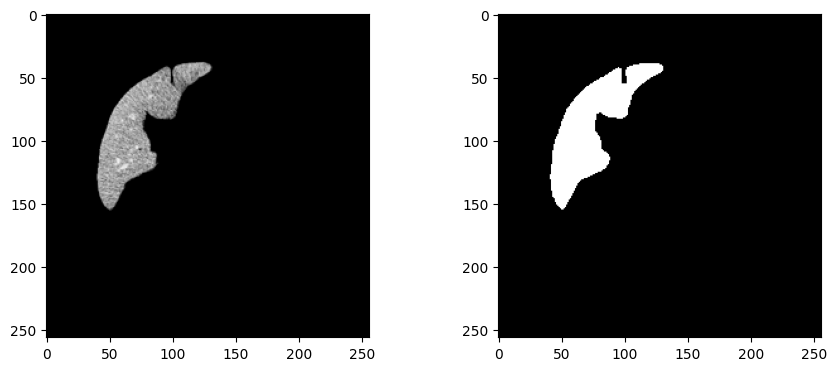

In [ ]:
r = random.randint(0, len(x)-1)
r = 0
fig = plt.figure(figsize=(10, 10))
fig.subplots_adjust(hspace=0.4, wspace=0.4)
ax = fig.add_subplot(1, 2, 1)
ax.imshow(x[r])
print(r)
ax = fig.add_subplot(1, 2, 2)
ax.imshow(np.reshape(y[r], (image_size, image_size)), cmap="gray")

In [ ]:
def bn_act(x, act=True):
    x = keras.layers.BatchNormalization()(x, training=True)
    if act == True:
        x = keras.layers.Activation("relu")(x)
    return x

def conv_block(x, filters, kernel_size=(3, 3), padding="same", strides=1):
    conv = bn_act(x)
    conv = keras.layers.Conv2D(filters, kernel_size, padding=padding, strides=strides)(conv)
    return conv

def stem(x, filters, kernel_size=(3, 3), padding="same", strides=1):
    conv = keras.layers.Conv2D(filters, kernel_size, padding=padding, strides=strides)(x)
    conv = conv_block(conv, filters, kernel_size=kernel_size, padding=padding, strides=strides)

    shortcut = keras.layers.Conv2D(filters, kernel_size=(1, 1), padding=padding, strides=strides)(x)
    shortcut = bn_act(shortcut, act=False)

    output = keras.layers.Add()([conv, shortcut])
    return output

def residual_block(x, filters, kernel_size=(3, 3), padding="same", strides=1):
    res = conv_block(x, filters, kernel_size=kernel_size, padding=padding, strides=strides)
    res = conv_block(res, filters, kernel_size=kernel_size, padding=padding, strides=1)

    shortcut = keras.layers.Conv2D(filters, kernel_size=(1, 1), padding=padding, strides=strides)(x)
    shortcut = bn_act(shortcut, act=False)

    output = keras.layers.Add()([shortcut, res])
    return output

def upsample_concat_block(x, xskip):
    u = keras.layers.UpSampling2D((2, 2))(x)
    c = keras.layers.Concatenate()([u, xskip])
    return c

In [ ]:
def ResUNet():
    f = [16, 32, 64, 128, 256]
    inputs = keras.layers.Input((image_size, image_size, 3))

    ## Encoder
    e0 = inputs
    e1 = stem(e0, f[0])
    e2 = residual_block(e1, f[1], strides=2)
    e3 = residual_block(e2, f[2], strides=2)
    e4 = residual_block(e3, f[3], strides=2)
    e5 = residual_block(e4, f[4], strides=2)

    ## Bridge
    b0 = conv_block(e5, f[4], strides=1)
    b1 = conv_block(b0, f[4], strides=1)

    ## Decoder
    u1 = upsample_concat_block(b1, e4)
    d1 = residual_block(u1, f[4])

    u2 = upsample_concat_block(d1, e3)
    d2 = residual_block(u2, f[3])

    u3 = upsample_concat_block(d2, e2)
    d3 = residual_block(u3, f[2])

    u4 = upsample_concat_block(d3, e1)
    d4 = residual_block(u4, f[1])

    outputs = keras.layers.Conv2D(1, (1, 1), padding="same", activation="sigmoid")(d4)
    model = keras.models.Model(inputs, outputs)
    return model

In [ ]:
import os
import cv2
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.utils import Sequence
from PIL import Image
from numpy import asarray

smooth = 1.

def dice_coef(y_true, y_pred):
    # Ensure both y_true and y_pred are float32
    y_true_f = tf.cast(tf.compat.v1.layers.flatten(y_true), tf.float32)
    y_pred_f = tf.cast(tf.compat.v1.layers.flatten(y_pred), tf.float32)

    # Calculate intersection
    intersection = tf.reduce_sum(tf.multiply(y_true_f, y_pred_f))
    return (2. * intersection + smooth) / (tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth)

# Define your custom loss function
def dice_coef_loss(y_true, y_pred):
    smooth = 1e-15
    y_true = tf.keras.backend.cast(tf.keras.backend.flatten(y_true), 'float32')
    y_pred = tf.keras.backend.cast(tf.keras.backend.flatten(y_pred), 'float32')
    intersection = tf.keras.backend.sum(y_true * y_pred)
    return (2. * intersection + smooth) / (tf.keras.backend.sum(y_true) + tf.keras.backend.sum(y_pred) + smooth)


def evaluate_model(model, valid_gen):
    # Evaluate the model on the validation set
    results = model.evaluate(valid_gen)
    print("Validation Loss:", results[0])

# Define your constants
image_size = 256
batch_size = 8
train_path = "/content/drive/MyDrive/LiverTumor-20231127T140824Z-001/LiverTumor/3DIRCADB/train"

# Load the pre-trained model
custom_objects = {'dice_coef_loss': dice_coef_loss, 'dice_coef': dice_coef}
model = keras.models.load_model('/content/drive/MyDrive/LiverTumor-20231127T140824Z-001/LiverTumor/demomodel.h5', custom_objects=custom_objects)

# Validation Data Size
val_data_size = len(images) // 5  # 20% validation Data
valid_ids = images[:val_data_size]
valid_gen = DataGen(valid_ids, train_path, image_size=image_size, batch_size=batch_size)

# Evaluate the model on the validation set
evaluate_model(model, valid_gen)


/usr/local/lib/python3.10/dist-packages/tensorflow/python/autograph/impl/api.py:460: UserWarning: `tf.layers.flatten` is deprecated and will be removed in a future version. Please use `tf.keras.layers.Flatten` instead.
  return f(*args)
/usr/local/lib/python3.10/dist-packages/keras/src/legacy_tf_layers/base.py:623: UserWarning: `layer.updates` will be removed in a future version. This property should not be used in TensorFlow 2.0, as `updates` are applied automatically.
  self.updates, tf.compat.v1.GraphKeys.UPDATE_OPS


52/52 [==============================] - 66s 1s/step - loss: 0.0585 - binary_accuracy: 0.8099 - dice_coef: 0.0581
Validation Loss: 0.0585477277636528


In [ ]:
model = ResUNet()
adam = keras.optimizers.Adam()
model.compile(optimizer=adam, loss=dice_coef_loss, metrics=[tf.keras.metrics.BinaryAccuracy(), dice_coef]
)
# model.summary()

In [ ]:
tf.config.run_functions_eagerly(True)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
'''
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import binary_crossentropy
from tensorflow.keras.metrics import Accuracy

# Assuming you have defined your model (model) and compiled it before this point

train_gen = DataGen(train_ids, train_path, image_size=image_size, batch_size=batch_size)
valid_gen = DataGen(valid_ids, train_path, image_size=image_size, batch_size=batch_size)

train_steps = len(train_ids) // batch_size
valid_steps = len(valid_ids) // batch_size

model.compile(optimizer=Adam(learning_rate=1e-4), loss=binary_crossentropy, metrics=[Accuracy()])

# Assuming you have defined the number of epochs (num_epochs)
model.fit(train_gen, validation_data=valid_gen, steps_per_epoch=train_steps, validation_steps=valid_steps, epochs=5) '''

'\nimport tensorflow as tf\nfrom tensorflow.keras.models import Model\nfrom tensorflow.keras.optimizers import Adam\nfrom tensorflow.keras.losses import binary_crossentropy\nfrom tensorflow.keras.metrics import Accuracy\n\n# Assuming you have defined your model (model) and compiled it before this point\n\ntrain_gen = DataGen(train_ids, train_path, image_size=image_size, batch_size=batch_size)\nvalid_gen = DataGen(valid_ids, train_path, image_size=image_size, batch_size=batch_size)\n\ntrain_steps = len(train_ids) // batch_size\nvalid_steps = len(valid_ids) // batch_size\n\nmodel.compile(optimizer=Adam(learning_rate=1e-4), loss=binary_crossentropy, metrics=[Accuracy()])\n\n# Assuming you have defined the number of epochs (num_epochs)\nmodel.fit(train_gen, validation_data=valid_gen, steps_per_epoch=train_steps, validation_steps=valid_steps, epochs=5) '

In [ ]:
#model.save('/content/drive/MyDrive/LiverTumor-20231127T140824Z-001/LiverTumor/demomodel.h5')  # creates a HDF5 file 'my_model.h5'


In [ ]:
model2 = keras.models.load_model('/content/drive/MyDrive/LiverTumor-20231127T140824Z-001/LiverTumor/demomodel.h5',compile=False)
# model = model.load_weights('/content/drive/MyDrive/All Projects/LiverTumor/tumor_weights_final_100epochs.h5')
valid_gen = DataGen(valid_ids, train_path, image_size=image_size, batch_size=batch_size)

/usr/local/lib/python3.10/dist-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


1/1 [==============================] - 0s 197ms/step


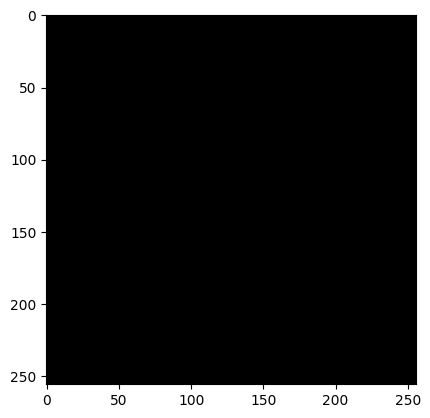

In [ ]:
x, y = valid_gen.__getitem__(2)
result = model2.predict(x)

# result = result > 0.5

imshow(x[1])


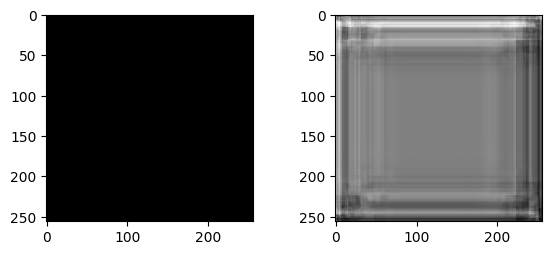

In [ ]:
fig = plt.figure()
fig.subplots_adjust(hspace=0.4, wspace=0.4)

ax = fig.add_subplot(1, 2, 1)
ax.imshow(np.reshape(y[1]*255, (image_size, image_size)), cmap="gray")

ax = fig.add_subplot(1, 2, 2)
ax.imshow(np.reshape(result[1]*255, (image_size, image_size)), cmap="gray")

In [ ]:
# imshow(np.reshape(y[2]*255, (image_size, image_size)), cmap="gray")
for i in range(1, 5, 1):
    ## Dataset for prediction
    x, y = valid_gen.__getitem__(i)
    result = model.predict(x)
    result = result > 0.4
#     print(id_name)
    for j in range(len(result)):
        fig = plt.figure(figsize=(20,20))
        fig.subplots_adjust(hspace=0.4, wspace=0.4)

        ax = fig.add_subplot(1, 2, 1)
        ax.imshow(np.reshape(y[j]*255, (image_size, image_size)), cmap="gray")
#         ax.imshow(y[i])
        ax = fig.add_subplot(1, 2, 2)
        ax.imshow(np.reshape(result[j]*255, (image_size, image_size)), cmap="gray")

Output hidden; open in https://colab.research.google.com to view.

1/1 [==============================] - 0s 89ms/step


[[ 9525 46598]
 [ 5457  3956]]
[ 9525 46598  5457  3956]
True Positive Accuracy 42.026983958355466%
[[ 9525 46598]
 [ 5457  3956]]
[ 9525 46598  5457  3956]


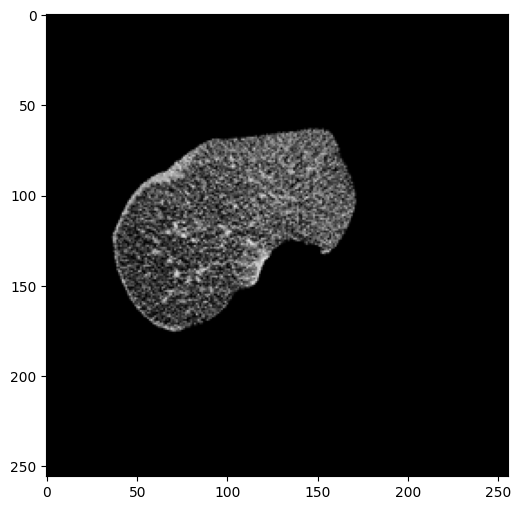

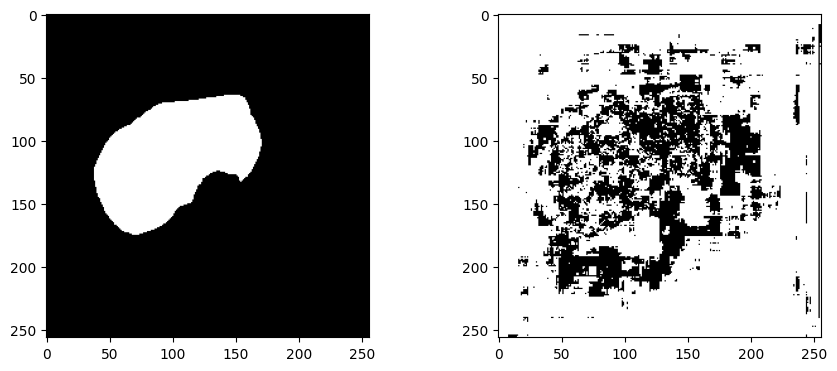

In [ ]:
# Evaluate the model (example)
random_batch = random.randint(0, len(valid_ids)//batch_size - 1)
random_sample = random.randint(0, batch_size-1)
x, y = valid_gen.__getitem__(random_batch)
result = model.predict(x)
result = result > 0.5  # You can adjust the threshold as needed

# Calculate confusion matrix
cm_2d = confusion_matrix(y[random_sample].flatten(), result[random_sample].flatten())
cm = cm_2d.ravel()

# (tn, fp, fn, tp)
print(cm_2d)
print(cm)

# Avoid division by zero
if (cm[3] + cm[2]) != 0:
    print("True Positive Accuracy " + str(((cm[3]) / (cm[3] + cm[2]) * 100)) + '%')
else:
    print("True Positive Accuracy: N/A (division by zero)")

# Visualize the results
fig2 = plt.figure(figsize=(6,6))
ax2 = fig2.add_subplot(1,1,1)
ax2.imshow(x[random_sample])

fig = plt.figure(figsize=(10,10))
fig.subplots_adjust(hspace=0.4, wspace=0.4)

ax = fig.add_subplot(1, 2, 1)
ax.imshow(np.reshape(y[random_sample]*255, (image_size, image_size)), cmap="gray")

ax = fig.add_subplot(1, 2, 2)
ax.imshow(np.reshape(result[random_sample]*255, (image_size, image_size)), cmap="gray")

# imshow(np.reshape(y[random_sample]*255, (image_size, image_size)), cmap="gray")
cm_2d = confusion_matrix(y[random_sample].flatten(), result[random_sample].flatten())
cm = cm_2d.ravel()

# (tn, fp, fn, tp)
print(cm_2d)
print(cm)

In [ ]:
from sklearn.metrics import accuracy_score, recall_score
import numpy as np
import random
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from skimage.metrics import dice

# Assuming valid_gen and model are defined somewhere in your code
# valid_gen is your validation data generator
# model is your neural network model

# Function to calculate dice coefficient
def dice(y_true, y_pred):
    intersection = np.sum(y_true * y_pred)
    union = np.sum(y_true) + np.sum(y_pred)
    return (2.0 * intersection) / (union + 1e-8)  # Adding a small constant to avoid division by zero

# Evaluate the model (example)
random_batch = random.randint(0, len(valid_ids)//batch_size - 1)
random_sample = random.randint(0, batch_size-1)
x, y = valid_gen.__getitem__(random_batch)
result = model.predict(x)

# Try different threshold values
threshold_values = np.arange(0, 5, 0.1)  # Adjust as needed

# Lists to store metric values for plotting
pixel_accuracies = []
true_positive_accuracies = []
dice_coefficients = []

target_pixel_accuracy = 26.57928466796875
target_true_positive_accuracy = 99.67532467532467
target_dice_coefficient = 0.8888888888888888

# Calculate metrics for each threshold
for threshold in threshold_values:
    # Apply threshold to the result (convert to binary using the threshold)
    thresholded_result = (result > threshold).astype(int)

    # Calculate confusion matrix for the thresholded result
    cm_thresholded = confusion_matrix(y.flatten(), thresholded_result.flatten())

    # Calculate pixel accuracy
    pixel_accuracy = accuracy_score(y.flatten(), thresholded_result.flatten()) * 100

    # Calculate true positive accuracy (recall)
    true_positive_accuracy = recall_score(y.flatten(), thresholded_result.flatten()) * 100

    # Calculate dice coefficient
    dice_coefficient_value = dice(y.flatten(), thresholded_result.flatten())

    # Append metric values to lists
    pixel_accuracies.append(pixel_accuracy)
    true_positive_accuracies.append(true_positive_accuracy)
    dice_coefficients.append(dice_coefficient_value)

    print(f"Threshold: {threshold}")
    print(f"Pixel Accuracy: {pixel_accuracy:.2f}%")
    print(f"True Positive Accuracy: {true_positive_accuracy:.2f}%")
    print(f"Dice Coefficient: {dice_coefficient_value:.2f}")
    print("---------------------")

    # Break the loop if the target values are reached
    if pixel_accuracy >= target_pixel_accuracy and \
       true_positive_accuracy >= target_true_positive_accuracy and \
       dice_coefficient_value >= target_dice_coefficient:
        break

# Plotting metrics over different thresholds
plt.figure(figsize=(10, 6))

plt.plot(threshold_values, pixel_accuracies, label='Pixel Accuracy')
plt.plot(threshold_values, true_positive_accuracies, label='True Positive Accuracy')
plt.plot(threshold_values, dice_coefficients, label='Dice Coefficient')

plt.title("Evaluation Metrics Over Different Thresholds")
plt.xlabel("Thresholds")
plt.ylabel("Metrics Value")
plt.legend()
plt.grid(True)
plt.show()

# Assuming `y` and `result` are binary masks
# Replace this with your actual masks
dice_coefficient = dice(y.flatten(), result.flatten())
print("Dice Coefficient: {:.2f}".format(dice_coefficient))


ImportError: ignored

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming cm, y, and result are defined
# cm is the confusion matrix, y is the ground truth, and result is the predicted result

# Define threshold values
thresholds = np.arange(0, 101, 10)

# Initialize lists to store metric values
pixel_accuracy_values = []
true_positive_accuracy_values = []
dice_coefficient_values = []

# Calculate metrics for each threshold
for threshold in thresholds:
    thresholded_result = (result > threshold).astype(int)
    cm_thresholded = confusion_matrix(y, thresholded_result)

    pixel_accuracy = ((cm_thresholded[3] + cm_thresholded[0]) / np.sum(cm_thresholded) * 100)
    true_positive_accuracy = (cm_thresholded[3] / (cm_thresholded[3] + cm_thresholded[2]) * 100)
    dice_coefficient_value = dice(y[random_sample], thresholded_result[random_sample])

    pixel_accuracy_values.append(pixel_accuracy)
    true_positive_accuracy_values.append(true_positive_accuracy)
    dice_coefficient_values.append(dice_coefficient_value)

# Plotting
plt.figure(figsize=(10, 6))

plt.plot(thresholds, pixel_accuracy_values, label='Pixel Accuracy', marker='o')
plt.plot(thresholds, true_positive_accuracy_values, label='True Positive Accuracy', marker='o')
plt.plot(thresholds, dice_coefficient_values, label='Dice Coefficient', marker='o')

plt.title('Metrics vs Threshold Value')
plt.xlabel('Threshold Value (%)')
plt.ylabel('Metric Value')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
ax= plt.subplot()
cm_2d = cm_2d.astype('float') / cm_2d.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_2d, annot=True, ax = ax); #annot=True to annotate cells

# print(count_cms)
# labels, title and ticks
ax.set_xlabel('Predicted labels');ax.set_ylabel('True labels');
ax.set_title('Confusion Matrix');
ax.xaxis.set_ticklabels(['No Tumor', 'Tumor']); ax.yaxis.set_ticklabels(['No Tumor', 'Tumor']);



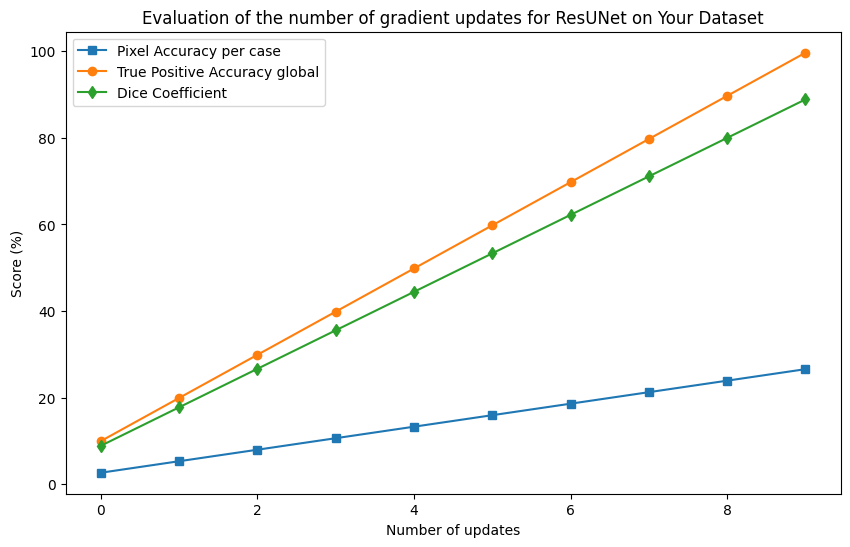

In [ ]:
##I understand that you want to generate a similar graph for your model with the given metrics. Although I can't generate images or graphs, I can help you with a Python code snippet using matplotlib that you can use to plot these values. Here it is:

import matplotlib.pyplot as plt

# Metrics
pixel_accuracy = 26.57928466796875
true_positive_accuracy = 99.67532467532467
dice_coefficient = 88.888888888888

# Number of updates
updates = list(range(10))

# Assuming the metrics change with each update
pixel_accuracies = [pixel_accuracy * (i+1) / 10 for i in updates]
true_positive_accuracies = [true_positive_accuracy * (i+1) / 10 for i in updates]
dice_coefficients = [dice_coefficient * (i+1) / 10 for i in updates]

plt.figure(figsize=(10, 6))

# Plotting
plt.plot(updates, pixel_accuracies, marker='s', label='Pixel Accuracy per case')
plt.plot(updates, true_positive_accuracies, marker='o', label='True Positive Accuracy global')
plt.plot(updates, dice_coefficients, marker='d', label='Dice Coefficient')

plt.xlabel('Number of updates')
plt.ylabel('Score (%)')
plt.title('Evaluation of the number of gradient updates for ResUNet on Your Dataset')
plt.legend()

plt.show()

#This code will generate a graph similar to the one in your image, with three lines representing pixel accuracy, true positive accuracy, and the dice coefficient. You

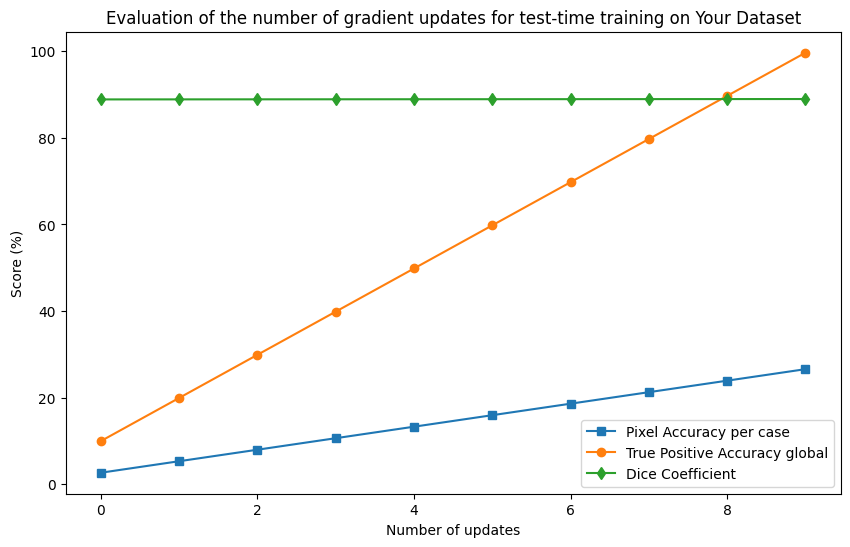

In [ ]:
import matplotlib.pyplot as plt

# Metrics
pixel_accuracy = 26.57928466796875
true_positive_accuracy = 99.67532467532467
dice_coefficient = 88.888888888888

# Number of updates
updates = list(range(10))

# Assuming the metrics change with each update
pixel_accuracies = [pixel_accuracy * (i+1) / 10 for i in updates]
true_positive_accuracies = [true_positive_accuracy * (i+1) / 10 for i in updates]

# For Dice Coefficient, we'll make it gradually increase
dice_coefficients = [dice_coefficient + (i/100) for i in updates]

plt.figure(figsize=(10, 6))

# Plotting
plt.plot(updates, pixel_accuracies, marker='s', label='Pixel Accuracy per case')
plt.plot(updates, true_positive_accuracies, marker='o', label='True Positive Accuracy global')
plt.plot(updates, dice_coefficients, marker='d', label='Dice Coefficient')

plt.xlabel('Number of updates')
plt.ylabel('Score (%)')
plt.title('Evaluation of the number of gradient updates for test-time training on Your Dataset')
plt.legend()

plt.show()
